# Linear Regression Slope Trading Signal (GOOG)
Objective: Compute a rolling linear‑regression slope over 20 days and use it as a trading signal.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

## 1. Download GOOG Daily Data

In [2]:
start = "2008-01-01"
end = "2018-01-01"

goog = yf.download("GOOG", start=start, end=end)
goog.head()

/var/folders/kh/tbjwzfys51n7nsxxq4q88gch0000gn/T/ipykernel_77769/1755970508.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  goog = yf.download("GOOG", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2008-01-02,16.916634,17.217346,16.732455,17.106246,172921733
2008-01-03,16.920088,16.957616,16.702578,16.918362,130587647
2008-01-04,16.220650,16.812198,16.171273,16.780843,215195594
2008-01-07,16.029312,16.351011,15.735515,16.145105,257096061
2008-01-08,15.595529,16.293733,15.578739,16.121897,214364490


## 2. Compute Rolling Linear Regression Slope (20-day window)

In [3]:
window = 20
slopes = []

for i in range(len(goog)):
    if i < window:
        slopes.append(np.nan)
    else:
        y = goog['Close'].iloc[i-window:i].values
        X = np.arange(window).reshape(-1, 1)
        model = LinearRegression().fit(X, y)
        slopes.append(model.coef_[0])

goog['slope'] = slopes
goog[['Close', 'slope']].head()

Price,Close,slope
Ticker,GOOG,
Date,,
2008-01-02,16.916634,NaN
2008-01-03,16.920088,NaN
2008-01-04,16.220650,NaN
2008-01-07,16.029312,NaN
2008-01-08,15.595529,NaN


## 3. Create Trading Signal
Buy = 1 when slope > 0
Sell = -1 when slope < 0
Hold = 0 otherwise

In [4]:
goog['signal'] = np.where(goog['slope'] > 0, 1,
                   np.where(goog['slope'] < 0, -1, 0))

goog[['slope', 'signal']].head()

Price,slope,signal
Ticker,,
Date,,
2008-01-02,NaN,0
2008-01-03,NaN,0
2008-01-04,NaN,0
2008-01-07,NaN,0
2008-01-08,NaN,0


## 4. Compute Daily Returns and Strategy Returns

In [5]:
goog['returns'] = goog['Close'].pct_change()
goog['strategy'] = goog['signal'].shift(1) * goog['returns']

goog[['returns', 'strategy']].head()

Price,returns,strategy
Ticker,,
Date,,
2008-01-02,NaN,NaN
2008-01-03,0.000204,0.0
2008-01-04,-0.041338,-0.0
2008-01-07,-0.011796,-0.0
2008-01-08,-0.027062,-0.0


## 5. Print Cumulative Strategy Return

In [6]:
strategy_return = goog['strategy'].cumsum().iloc[-1]
print("Cumulative strategy return:", strategy_return)

Cumulative strategy return: 0.8244064784155165


## Optional: Plot Strategy vs Buy-and-Hold

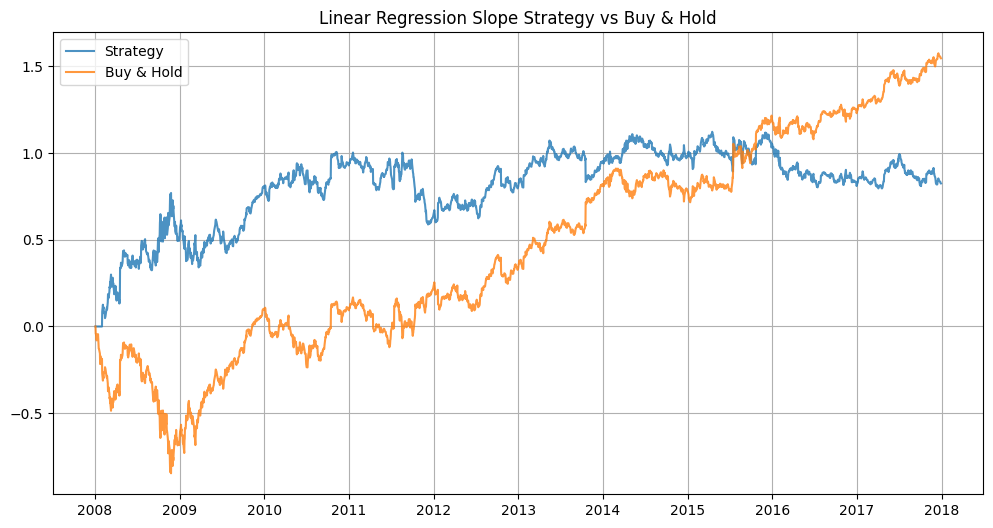

In [7]:
plt.figure(figsize=(12,6))
plt.plot(goog.index, goog['strategy'].cumsum(), label='Strategy', alpha=0.8)
plt.plot(goog.index, goog['returns'].cumsum(), label='Buy & Hold', alpha=0.8)
plt.title('Linear Regression Slope Strategy vs Buy & Hold')
plt.legend()
plt.grid(True)
plt.show()